# MCDI503 · Exploración Inteligente de Datos
## Evaluación Sumativa 3 · Fase 4 · Pipeline exploratorio reproducible

**Dataset:** Titanic (Seaborn)  
**Integrantes:** Luis Díaz · Gonzalo Bouldres · Eduardo Contreras  
**Grupo:** 6

### Propósito
Implementar el cierre técnico del proyecto mediante un pipeline reproducible que continúe el trabajo de preparación y análisis exploratorio de las Fases 2 y 3. El flujo documenta transformaciones y normalizaciones, creación de variables derivadas, selección preliminar de características, generación de una matriz candidata para modelamiento y validación del dataset final.

El notebook documenta la ejecución final del pipeline de principio a fin. Las interpretaciones cuantitativas del informe y la presentación se sustentan exclusivamente en las evidencias producidas por esta corrida.

## I. Encabezado e identificación del notebook

El trabajo mantiene continuidad con la Sumativa 2. La versión preparada en dicha fase se utiliza como estado inicial de la Fase 4, mientras que el archivo original se conserva para trazabilidad y verificación de procedencia.

**Objetivo del cierre:** construir y documentar un pipeline exploratorio reproducible que transforme variables, genere representaciones derivadas y establezca una selección preliminar de características sin entrenar ni evaluar todavía un modelo predictivo.

**Alcance y valor analítico:** el resultado de esta fase debe dejar un conjunto enriquecido, una matriz candidata de características y evidencia auditable de las decisiones adoptadas. Estos productos permiten pasar del EDA a una etapa posterior de modelamiento de manera trazable, evitando que una decisión de preparación o selección quede implícita.


## II. Carga de datos y preparación del entorno

Esta sección localiza la raíz del proyecto, importa las librerías, crea las carpetas de salida, registra versiones del entorno y carga los dos insumos: el dataset original y el dataset preparado en las Fases 2 y 3.

In [12]:
from pathlib import Path
import hashlib
import json
import platform
import sys
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)

# Localización robusta de la raíz del proyecto.
start = Path.cwd().resolve()
candidates = [start] + list(start.parents)
ROOT = next((p for p in candidates if (p / 'data' / 'input' / 'titanic_f23_prepared.csv').exists()), None)
if ROOT is None:
    raise FileNotFoundError(
        'No se encontró data/input/titanic_f23_prepared.csv. '
        'Ejecute el notebook manteniendo la estructura completa de la carpeta del proyecto.'
    )

DATA_INPUT = ROOT / 'data' / 'input'
DATA_PROCESS = ROOT / 'data' / 'process'
OUTPUTS = ROOT / 'outputs'
FIGURES = ROOT / 'figures'
REPORTS = ROOT / 'reports'
PRESENTATION = ROOT / 'presentation'

for folder in [DATA_PROCESS, OUTPUTS, FIGURES, REPORTS, PRESENTATION]:
    folder.mkdir(parents=True, exist_ok=True)

# La corrida es determinística: se eliminan únicamente artefactos técnicos generados
# por ejecuciones anteriores. No se eliminan reports/ ni presentation/.
for folder in [DATA_PROCESS, OUTPUTS, FIGURES]:
    for path in folder.iterdir():
        if path.is_file() and path.name != '.gitkeep':
            path.unlink()

RAW_PATH = DATA_INPUT / 'titanic.csv'
PREP_PATH = DATA_INPUT / 'titanic_f23_prepared.csv'

if not RAW_PATH.exists():
    raise FileNotFoundError(f'No se encontró el dataset original: {RAW_PATH}')
if not PREP_PATH.exists():
    raise FileNotFoundError(f'No se encontró el dataset preparado: {PREP_PATH}')

raw = pd.read_csv(RAW_PATH)
base = pd.read_csv(PREP_PATH)


def sha256_file(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b''):
            h.update(chunk)
    return h.hexdigest()


environment = pd.DataFrame([
    {'componente':'Python', 'version':platform.python_version()},
    {'componente':'pandas', 'version':pd.__version__},
    {'componente':'numpy', 'version':np.__version__},
    {'componente':'matplotlib', 'version':plt.matplotlib.__version__},
    {'componente':'seaborn', 'version':sns.__version__},
])
environment.to_csv(OUTPUTS / '00_entorno_ejecucion.csv', index=False)

source_manifest = pd.DataFrame([
    {'archivo':RAW_PATH.name, 'filas':len(raw), 'columnas':raw.shape[1], 'sha256':sha256_file(RAW_PATH)},
    {'archivo':PREP_PATH.name, 'filas':len(base), 'columnas':base.shape[1], 'sha256':sha256_file(PREP_PATH)},
])
source_manifest.to_csv(OUTPUTS / '01_fuentes_entrada.csv', index=False)

print('Raíz del proyecto:', ROOT)
print('Dataset original:', raw.shape)
print('Dataset preparado Fases 2-3:', base.shape)
display(environment)
display(source_manifest)


Raíz del proyecto: C:\Users\juani\Downloads\MCDI503_F4_Sumativa_Grupo6_PARA_EJECUTAR_CORREGIDA\MCDI503_F4_Sumativa_Grupo6_PARA_EJECUTAR_CORREGIDA
Dataset original: (891, 15)
Dataset preparado Fases 2-3: (891, 29)


,componente,version
0,Python,3.12.4
1,pandas,2.2.2
2,numpy,1.26.4
3,matplotlib,3.8.4
4,seaborn,0.13.2


,archivo,filas,columnas,sha256
0,titanic.csv,891,15,81787d320d7f7b03df935e91de8bd19e11d45c5bbcab86...
1,titanic_f23_prepared.csv,891,29,65f88a53de8e8212f87232b4535943dd7f15e65608fe8a...


## III. Revisión inicial del dataset

Se verifica la estructura del dataset recibido desde las fases anteriores, la unicidad de la clave técnica, la presencia de las variables requeridas y el estado de valores faltantes. También se recalculan métricas exploratorias de referencia que servirán como evidencia para justificar las transformaciones de la Fase 4.

In [13]:
required = [
    'row_id','survived','pclass','sex','age','fare','sibsp','parch',
    'age_clean','embarked_clean','family_size','family_group','age_group','fare_log1p'
]
missing_required = [c for c in required if c not in base.columns]
if missing_required:
    raise ValueError(f'Faltan columnas requeridas en la base preparada: {missing_required}')

original_columns_preserved = all(c in base.columns for c in raw.columns)
original_values_preserved = original_columns_preserved and raw.equals(base[raw.columns])

# La clave row_id fue creada en fases anteriores como identificador técnico de fila.
# Su convención puede ser 0..n-1 o 1..n según la corrida que generó el CSV.
# Para continuidad y trazabilidad importa que sea numérica, entera, única,
# consecutiva, ascendente y que se preserve sin alteraciones durante la Fase 4.
def row_id_audit(series):
    numeric = pd.to_numeric(series, errors='coerce')
    numeric_ok = bool(numeric.notna().all())
    if not numeric_ok:
        return {
            'numeric_ok': False,
            'integer_like_ok': False,
            'consecutive_ok': False,
            'start': np.nan,
            'end': np.nan,
        }
    values = numeric.to_numpy(dtype=float)
    integer_like_ok = bool(np.allclose(values, np.round(values), rtol=0, atol=1e-12))
    consecutive_ok = bool(len(values) <= 1 or np.allclose(np.diff(values), 1.0, rtol=0, atol=1e-12))
    return {
        'numeric_ok': numeric_ok,
        'integer_like_ok': integer_like_ok,
        'consecutive_ok': consecutive_ok,
        'start': float(values[0]) if len(values) else np.nan,
        'end': float(values[-1]) if len(values) else np.nan,
    }

row_id_info = row_id_audit(base['row_id'])
row_id_sequence_ok = (
    row_id_info['numeric_ok']
    and row_id_info['integer_like_ok']
    and row_id_info['consecutive_ok']
)

initial_review = pd.DataFrame({
    'variable': base.columns,
    'tipo': [str(base[c].dtype) for c in base.columns],
    'n_unicos': [base[c].nunique(dropna=True) for c in base.columns],
    'n_missing': [base[c].isna().sum() for c in base.columns],
    'pct_missing': [base[c].isna().mean() * 100 for c in base.columns],
})
initial_review.to_csv(OUTPUTS / '02_revision_inicial_f4.csv', index=False)

initial_checks = pd.DataFrame([
    {'control':'Filas base preparada = filas originales', 'resultado':len(base) == len(raw)},
    {'control':'La base preparada conserva las 15 columnas originales', 'resultado':original_columns_preserved},
    {'control':'Los valores de las columnas originales permanecen sin modificación', 'resultado':original_values_preserved},
    {'control':'row_id existe y no tiene missing', 'resultado':base['row_id'].notna().all()},
    {'control':'row_id es numérico y representa valores enteros', 'resultado':row_id_info['numeric_ok'] and row_id_info['integer_like_ok']},
    {'control':'row_id es único', 'resultado':base['row_id'].is_unique},
    {'control':'row_id mantiene una secuencia consecutiva ascendente', 'resultado':row_id_sequence_ok},
    {'control':'survived pertenece a {0,1}', 'resultado':base['survived'].dropna().isin([0,1]).all()},
    {'control':'survived no presenta missing', 'resultado':base['survived'].notna().all()},
    {'control':'age_clean sin missing', 'resultado':base['age_clean'].notna().all()},
    {'control':'fare sin missing', 'resultado':base['fare'].notna().all()},
    {'control':'fare sin valores negativos', 'resultado':(base['fare'] >= 0).all()},
    {'control':'embarked_clean sin missing', 'resultado':base['embarked_clean'].notna().all()},
    {'control':'family_size sin missing y >= 1', 'resultado':base['family_size'].notna().all() and (base['family_size'] >= 1).all()},
])
initial_checks.to_csv(OUTPUTS / '03_controles_entrada.csv', index=False)

# Evidencia de referencia recalculada durante esta corrida.
eda_reference = {
    'fare_skewness': float(base['fare'].skew()),
    'fare_log1p_previo_skewness': float(base['fare_log1p'].skew()),
    'age_clean_mean': float(base['age_clean'].mean()),
    'age_clean_std': float(base['age_clean'].std(ddof=0)),
    'family_size_max': float(base['family_size'].max()),
    'survival_rate_overall': float(base['survived'].mean()),
}
pd.DataFrame([eda_reference]).to_csv(OUTPUTS / '04_evidencia_eda_recalculada.csv', index=False)

print('Controles iniciales:')
display(initial_checks)
print('Variables con valores faltantes al inicio de Fase 4:')
display(initial_review.loc[initial_review['n_missing'] > 0].sort_values('pct_missing', ascending=False))
print('Métricas de referencia recalculadas en esta ejecución:')
display(pd.DataFrame([eda_reference]))
print(
    'Convención row_id detectada:',
    f"inicio={row_id_info['start']:.0f}, fin={row_id_info['end']:.0f}, n={len(base)}"
)

if not initial_checks['resultado'].all():
    failed = initial_checks.loc[~initial_checks['resultado'], 'control'].tolist()
    raise AssertionError(f'Fallaron controles de entrada: {failed}')


Controles iniciales:


,control,resultado
0,Filas base preparada = filas originales,True
1,La base preparada conserva las 15 columnas ori...,True
2,Los valores de las columnas originales permane...,True
3,row_id existe y no tiene missing,True
4,row_id es numérico y representa valores enteros,True
5,row_id es único,True
6,row_id mantiene una secuencia consecutiva asce...,True
7,"survived pertenece a {0,1}",True
8,survived no presenta missing,True
9,age_clean sin missing,True


Variables con valores faltantes al inicio de Fase 4:


,variable,tipo,n_unicos,n_missing,pct_missing
12,deck,object,7,688,77.216611
4,age,float64,88,177,19.865320
8,embarked,object,3,2,0.224467
13,embark_town,object,3,2,0.224467


Métricas de referencia recalculadas en esta ejecución:


,fare_skewness,fare_log1p_previo_skewness,age_clean_mean,age_clean_std,family_size_max,survival_rate_overall
0,4.787317,0.394928,29.112424,13.296956,11.0,0.383838


Convención row_id detectada: inicio=1, fin=891, n=891


## IV. Transformaciones y normalizaciones aplicadas

Las transformaciones se aplican sobre una copia del dataset preparado de las Fases 2 y 3. Durante la ejecución se recalcularán las métricas necesarias para documentar la forma y escala de las variables antes y después de cada operación. La transformación `log1p` de `fare` se reconstruirá explícitamente en esta fase y se contrastará con la versión preparada previamente; posteriormente se generarán representaciones estandarizadas mediante z-score.

La auditoría registrará, para cada operación, la variable de origen, la variable resultante, la evidencia calculada que la fundamenta, el propósito técnico y las métricas antes y después. Ningún valor cuantitativo se fija de antemano en el notebook.


In [14]:
work = base.copy(deep=True)

# Reconstrucción explícita de la transformación logarítmica en Fase 4.
work['fare_log1p_f4'] = np.log1p(work['fare'].astype(float))
log_consistent = np.allclose(
    base['fare_log1p'].astype(float),
    work['fare_log1p_f4'].astype(float),
    equal_nan=True
)
if not log_consistent:
    raise AssertionError(
        'La transformación fare_log1p de Fases 2-3 no coincide con np.log1p(fare). '
        'Se detiene la ejecución para no ocultar una inconsistencia de entrada.'
    )

# Estandarización z con parámetros calculados sobre la base de trabajo actual.
def zscore(series):
    s = series.astype(float)
    mean = s.mean()
    std = s.std(ddof=0)
    if not np.isfinite(std) or std == 0:
        raise ValueError(f'No es posible estandarizar {series.name}: desviación estándar inválida.')
    return (s - mean) / std, mean, std

work['age_z'], age_mean, age_std = zscore(work['age_clean'])
work['fare_log1p_z'], fare_log_mean, fare_log_std = zscore(work['fare_log1p_f4'])

def stats_row(series):
    s = series.astype(float)
    return {
        'media': float(s.mean()),
        'desviacion_estandar': float(s.std(ddof=0)),
        'asimetria': float(s.skew()),
        'minimo': float(s.min()),
        'maximo': float(s.max()),
    }

fare_stats = stats_row(work['fare'])
fare_log_stats = stats_row(work['fare_log1p_f4'])
age_stats = stats_row(work['age_clean'])
age_z_stats = stats_row(work['age_z'])
fare_z_stats = stats_row(work['fare_log1p_z'])

transformation_audit = pd.DataFrame([
    {
        'variable_origen':'fare',
        'variable_resultado':'fare_log1p_f4',
        'operacion':'log1p',
        'evidencia_calculada':f"Asimetría antes = {fare_stats['asimetria']:.4f}; asimetría después = {fare_log_stats['asimetria']:.4f}.",
        'proposito':'Evaluar una representación que reduzca asimetría y preserve observaciones y valores cero.',
        'media_antes':fare_stats['media'],
        'media_despues':fare_log_stats['media'],
        'std_antes':fare_stats['desviacion_estandar'],
        'std_despues':fare_log_stats['desviacion_estandar'],
        'skew_antes':fare_stats['asimetria'],
        'skew_despues':fare_log_stats['asimetria'],
    },
    {
        'variable_origen':'age_clean',
        'variable_resultado':'age_z',
        'operacion':'z-score',
        'evidencia_calculada':f"Media antes = {age_stats['media']:.4f}; desviación estándar antes = {age_stats['desviacion_estandar']:.4f}.",
        'proposito':'Obtener una representación centrada y de desviación estándar unitaria para comparabilidad y eventual modelamiento sensible a escala.',
        'media_antes':age_stats['media'],
        'media_despues':age_z_stats['media'],
        'std_antes':age_stats['desviacion_estandar'],
        'std_despues':age_z_stats['desviacion_estandar'],
        'skew_antes':age_stats['asimetria'],
        'skew_despues':age_z_stats['asimetria'],
    },
    {
        'variable_origen':'fare_log1p_f4',
        'variable_resultado':'fare_log1p_z',
        'operacion':'z-score',
        'evidencia_calculada':f"Media antes = {fare_log_stats['media']:.4f}; desviación estándar antes = {fare_log_stats['desviacion_estandar']:.4f}.",
        'proposito':'Llevar la representación logarítmica de tarifa a una escala centrada y comparable.',
        'media_antes':fare_log_stats['media'],
        'media_despues':fare_z_stats['media'],
        'std_antes':fare_log_stats['desviacion_estandar'],
        'std_despues':fare_z_stats['desviacion_estandar'],
        'skew_antes':fare_log_stats['asimetria'],
        'skew_despues':fare_z_stats['asimetria'],
    },
])
transformation_audit.to_csv(OUTPUTS / '05_auditoria_transformaciones.csv', index=False)

print('Consistencia entre fare_log1p previo y la reconstrucción de Fase 4:', log_consistent)
display(transformation_audit)


Consistencia entre fare_log1p previo y la reconstrucción de Fase 4: True


,variable_origen,variable_resultado,operacion,evidencia_calculada,proposito,media_antes,media_despues,std_antes,std_despues,skew_antes,skew_despues
0,fare,fare_log1p_f4,log1p,Asimetría antes = 4.7873; asimetría después = ...,Evaluar una representación que reduzca asimetr...,32.204208,2.962246e+00,49.665534,0.968504,4.787317,0.394928
1,age_clean,age_z,z-score,Media antes = 29.1124; desviación estándar ant...,Obtener una representación centrada y de desvi...,29.112424,2.232906e-16,13.296956,1.000000,0.534083,0.534083
2,fare_log1p_f4,fare_log1p_z,z-score,Media antes = 2.9622; desviación estándar ante...,Llevar la representación logarítmica de tarifa...,2.962246,-1.903951e-16,0.968504,1.000000,0.394928,0.394928


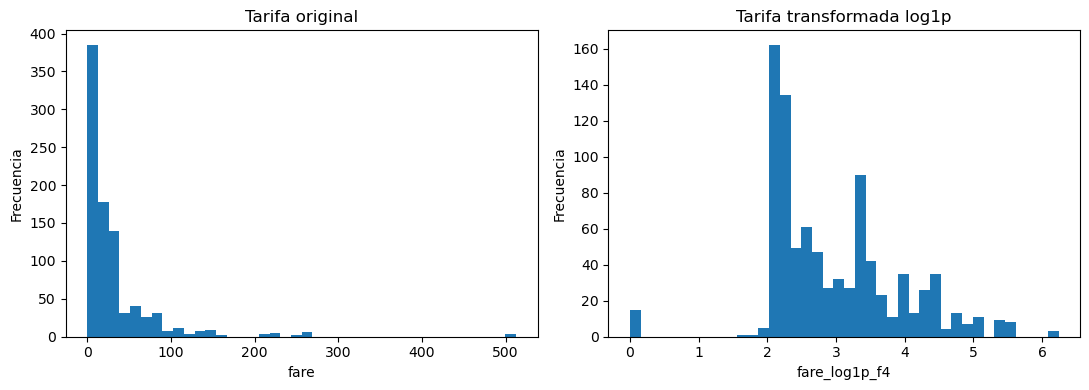

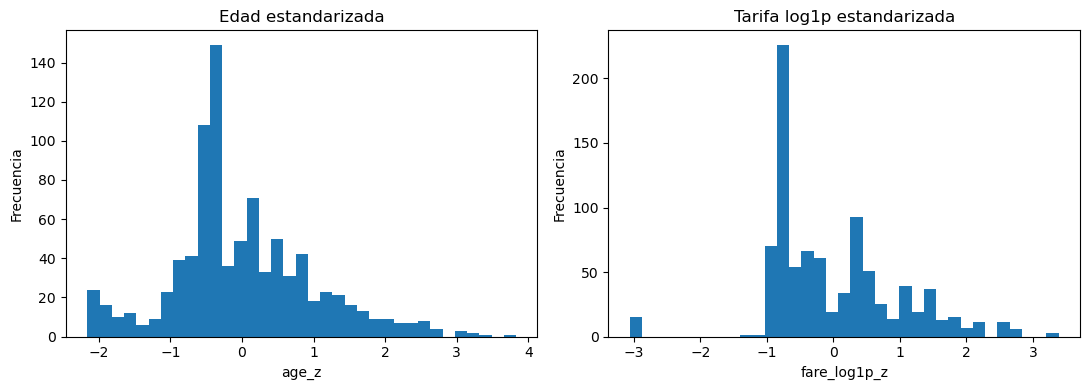

In [15]:
# Figura 1: efecto de la transformación logarítmica de tarifa.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(work['fare'].dropna(), bins=40)
axes[0].set_title('Tarifa original')
axes[0].set_xlabel('fare')
axes[0].set_ylabel('Frecuencia')
axes[1].hist(work['fare_log1p_f4'].dropna(), bins=40)
axes[1].set_title('Tarifa transformada log1p')
axes[1].set_xlabel('fare_log1p_f4')
axes[1].set_ylabel('Frecuencia')
fig.tight_layout()
fig.savefig(FIGURES / '01_transformacion_fare.png', dpi=160, bbox_inches='tight')
plt.show()

# Figura 2: variables estandarizadas.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(work['age_z'].dropna(), bins=35)
axes[0].set_title('Edad estandarizada')
axes[0].set_xlabel('age_z')
axes[0].set_ylabel('Frecuencia')
axes[1].hist(work['fare_log1p_z'].dropna(), bins=35)
axes[1].set_title('Tarifa log1p estandarizada')
axes[1].set_xlabel('fare_log1p_z')
axes[1].set_ylabel('Frecuencia')
fig.tight_layout()
fig.savefig(FIGURES / '02_variables_normalizadas.png', dpi=160, bbox_inches='tight')
plt.show()

## V. Variables derivadas o creadas

Se incorporan variables derivadas con reglas explícitas y trazables. La construcción busca representar umbrales, posibles interacciones y formas no lineales sin sustituir las variables de origen. La utilidad definitiva de estas variables se evaluará después de observar los resultados producidos por la ejecución.

In [16]:
# Variables derivadas de Fase 4.
work['is_minor'] = (work['age_clean'] < 16).astype('int8')
work['sex_pclass'] = work['sex'].astype(str).str.lower() + '_pclass_' + work['pclass'].astype(int).astype(str)
work['family_size_sq'] = work['family_size'].astype(float) ** 2
work['has_family'] = (work['family_size'] > 1).astype('int8')

feature_derivation = pd.DataFrame([
    {
        'variable_nueva':'is_minor',
        'variables_origen':'age_clean',
        'regla':'1 si age_clean < 16; 0 en otro caso',
        'utilidad_esperada':'Representar un umbral etario interpretable sin reemplazar la edad continua.'
    },
    {
        'variable_nueva':'sex_pclass',
        'variables_origen':'sex + pclass',
        'regla':'Concatenación categórica de sexo y clase',
        'utilidad_esperada':'Permitir revisar una interacción entre dos dimensiones relevantes del análisis previo.'
    },
    {
        'variable_nueva':'family_size_sq',
        'variables_origen':'family_size',
        'regla':'family_size ** 2',
        'utilidad_esperada':'Representar una posible relación no lineal del tamaño familiar.'
    },
    {
        'variable_nueva':'has_family',
        'variables_origen':'family_size',
        'regla':'1 si family_size > 1; 0 si viaja solo según parentescos registrados',
        'utilidad_esperada':'Disponer de una representación binaria interpretable del acompañamiento familiar registrado.'
    },
])
feature_derivation.to_csv(OUTPUTS / '06_variables_derivadas.csv', index=False)

display(feature_derivation)
print('Vista de variables derivadas:')
display(work[['row_id','age_clean','is_minor','sex','pclass','sex_pclass','family_size','family_size_sq','has_family']].head(10))

,variable_nueva,variables_origen,regla,utilidad_esperada
0,is_minor,age_clean,1 si age_clean < 16; 0 en otro caso,Representar un umbral etario interpretable sin...
1,sex_pclass,sex + pclass,Concatenación categórica de sexo y clase,Permitir revisar una interacción entre dos dim...
2,family_size_sq,family_size,family_size ** 2,Representar una posible relación no lineal del...
3,has_family,family_size,1 si family_size > 1; 0 si viaja solo según pa...,Disponer de una representación binaria interpr...


Vista de variables derivadas:


,row_id,age_clean,is_minor,sex,pclass,sex_pclass,family_size,family_size_sq,has_family
0,1,22.0,0,male,3,male_pclass_3,2,4.0,1
1,2,38.0,0,female,1,female_pclass_1,2,4.0,1
2,3,26.0,0,female,3,female_pclass_3,1,1.0,0
3,4,35.0,0,female,1,female_pclass_1,2,4.0,1
4,5,35.0,0,male,3,male_pclass_3,1,1.0,0
5,6,25.0,0,male,3,male_pclass_3,1,1.0,0
6,7,54.0,0,male,1,male_pclass_1,1,1.0,0
7,8,2.0,1,male,3,male_pclass_3,5,25.0,1
8,9,27.0,0,female,3,female_pclass_3,3,9.0,1
9,10,14.0,1,female,2,female_pclass_2,2,4.0,1


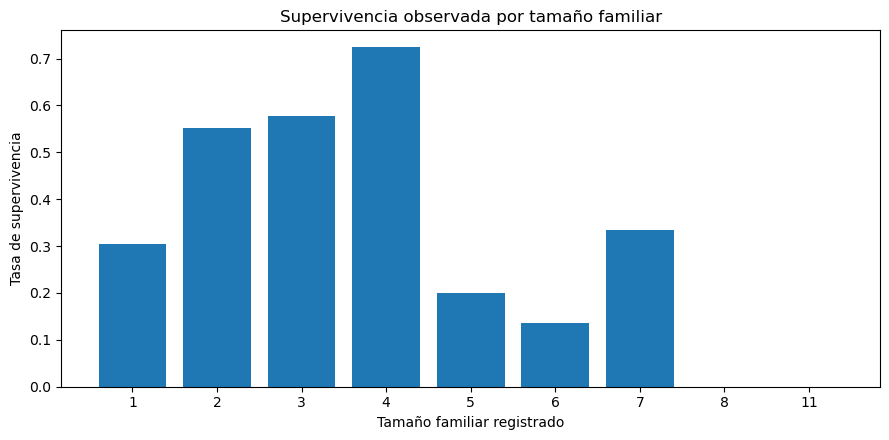

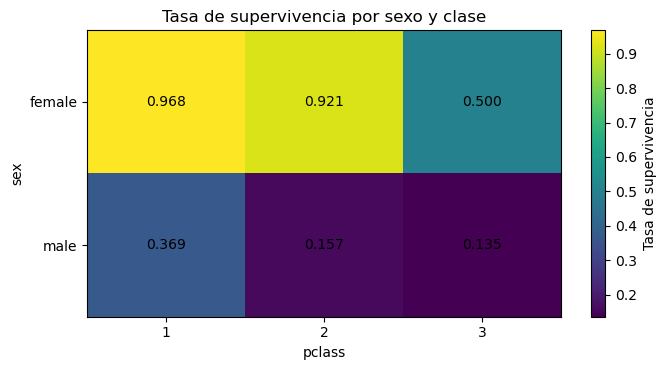

Evidencia por tamaño familiar:


,family_size,tasa_supervivencia,n
0,1,0.303538,537
1,2,0.552795,161
2,3,0.578431,102
3,4,0.724138,29
4,5,0.200000,15
5,6,0.136364,22
6,7,0.333333,12
7,8,0.000000,6
8,11,0.000000,7


Evidencia por sexo y clase:


,sex,pclass,tasa_supervivencia,n
0,female,1,0.968085,94
1,female,2,0.921053,76
2,female,3,0.500000,144
3,male,1,0.368852,122
4,male,2,0.157407,108
5,male,3,0.135447,347


In [17]:
# Evidencia exploratoria dinámica para las variables derivadas.
family_evidence = (
    work.groupby('family_size', observed=False)['survived']
        .agg(tasa_supervivencia='mean', n='size')
        .reset_index()
)
family_evidence.to_csv(OUTPUTS / '07_evidencia_family_size.csv', index=False)

sex_class_evidence = (
    work.groupby(['sex','pclass'], observed=False)['survived']
        .agg(tasa_supervivencia='mean', n='size')
        .reset_index()
)
sex_class_evidence.to_csv(OUTPUTS / '08_evidencia_sex_pclass.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(family_evidence['family_size'].astype(str), family_evidence['tasa_supervivencia'])
ax.set_xlabel('Tamaño familiar registrado')
ax.set_ylabel('Tasa de supervivencia')
ax.set_title('Supervivencia observada por tamaño familiar')
fig.tight_layout()
fig.savefig(FIGURES / '03_family_size_supervivencia.png', dpi=160, bbox_inches='tight')
plt.show()

pivot = work.pivot_table(index='sex', columns='pclass', values='survived', aggfunc='mean', observed=False)
fig, ax = plt.subplots(figsize=(7, 3.8))
im = ax.imshow(pivot.values, aspect='auto')
ax.set_xticks(range(len(pivot.columns)), [str(x) for x in pivot.columns])
ax.set_yticks(range(len(pivot.index)), [str(x) for x in pivot.index])
ax.set_title('Tasa de supervivencia por sexo y clase')
ax.set_xlabel('pclass')
ax.set_ylabel('sex')
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f'{pivot.iloc[i, j]:.3f}', ha='center', va='center')
fig.colorbar(im, ax=ax, label='Tasa de supervivencia')
fig.tight_layout()
fig.savefig(FIGURES / '04_interaccion_sex_pclass.png', dpi=160, bbox_inches='tight')
plt.show()

print('Evidencia por tamaño familiar:')
display(family_evidence)
print('Evidencia por sexo y clase:')
display(sex_class_evidence)

## VI. Selección preliminar de características

La selección se documenta mediante criterios explícitos: relevancia analítica observada en el EDA, riesgo de fuga de información, redundancia semántica, interpretabilidad, consistencia, calidad de datos y posible utilidad para modelamiento posterior. Se distinguen variables seleccionadas, variables sujetas a revisión y variables descartadas. Las métricas calculadas durante la corrida funcionan como evidencia de apoyo y no sustituyen el criterio conceptual.

La matriz candidata se construye únicamente con las variables clasificadas como `seleccionar`. Los identificadores y la variable objetivo se mantienen fuera de la matriz de características. Para variables categóricas se utiliza codificación one-hot con categoría de referencia (`drop_first=True`) para evitar redundancia lineal perfecta en modelos que incorporen intercepto.

In [18]:
# Métricas de apoyo calculadas sobre la corrida actual.
def binary_corr(series, target):
    x = pd.to_numeric(series, errors='coerce')
    y = pd.to_numeric(target, errors='coerce')
    valid = x.notna() & y.notna()
    if valid.sum() < 3 or x[valid].nunique() < 2:
        return np.nan
    return float(x[valid].corr(y[valid]))

support_metrics = []
for c in work.columns:
    row = {
        'variable':c,
        'tipo':str(work[c].dtype),
        'n_unicos':int(work[c].nunique(dropna=True)),
        'pct_missing':float(work[c].isna().mean()*100),
        'corr_survived':np.nan,
        'rango_tasas_survived':np.nan,
    }
    if pd.api.types.is_numeric_dtype(work[c]) and c != 'survived':
        row['corr_survived'] = binary_corr(work[c], work['survived'])
    elif c != 'survived' and work[c].nunique(dropna=True) <= 20:
        rates = work.groupby(c, observed=False)['survived'].mean().dropna()
        if len(rates) > 1:
            row['rango_tasas_survived'] = float(rates.max() - rates.min())
    support_metrics.append(row)
support_metrics = pd.DataFrame(support_metrics)
support_metrics.to_csv(OUTPUTS / '09_metricas_apoyo_seleccion.csv', index=False)

# Decisiones preliminares explícitas.
family_min = family_evidence.loc[family_evidence['tasa_supervivencia'].idxmin()]
family_max = family_evidence.loc[family_evidence['tasa_supervivencia'].idxmax()]
sex_class_min = sex_class_evidence.loc[sex_class_evidence['tasa_supervivencia'].idxmin()]
sex_class_max = sex_class_evidence.loc[sex_class_evidence['tasa_supervivencia'].idxmax()]

selection_rows = [
    ('survived','objetivo','Variable objetivo','Resultado a explicar; se mantiene separado de la matriz X.'),
    ('row_id','descartar','Identificador','Clave técnica para trazabilidad; no posee significado predictivo y no se incorpora a X.'),
    ('age_z','seleccionar','Relevancia + escala','Edad preparada sin faltantes y estandarizada; conserva información continua y queda en escala comparable.'),
    ('fare_log1p_z','seleccionar','Relevancia + transformación',f"La corrida calcula una asimetría de fare de {work['fare'].skew():.3f} y de fare_log1p_f4 de {work['fare_log1p_f4'].skew():.3f}; se prioriza la versión estandarizada como representación candidata."),
    ('pclass','seleccionar','Relevancia + interpretabilidad','Clase del pasajero; variable central del EDA previo, interpretable y no sustituida por otra representación seleccionada.'),
    ('sex','seleccionar','Relevancia + interpretabilidad',f"Las tasas de supervivencia difieren entre categorías; el rango observado de tasas por sexo es {support_metrics.loc[support_metrics.variable=='sex','rango_tasas_survived'].iloc[0]:.3f}."),
    ('embarked_clean','seleccionar','Consistencia + contexto','Puerto de embarque preparado sin faltantes; conserva una dimensión contextual no equivalente a las otras variables seleccionadas.'),
    ('family_size','seleccionar','Relevancia + interpretabilidad',f"El EDA muestra un patrón no monótono por tamaño familiar: la tasa mínima observada es {family_min.tasa_supervivencia:.3f} y la máxima {family_max.tasa_supervivencia:.3f}."),
    ('family_size_sq','seleccionar','No linealidad','Término polinómico complementario a family_size para representar curvatura potencial sugerida por el patrón no monótono del EDA.'),
    ('is_minor','seleccionar','Interpretabilidad + umbral','Representación binaria explícita del umbral etario <16 años, coherente con la categorización de edad usada en fases previas.'),
    ('sex_pclass','revisar','Interacción + redundancia potencial',f"La combinación sexo-clase presenta un rango de tasas de supervivencia de {support_metrics.loc[support_metrics.variable=='sex_pclass','rango_tasas_survived'].iloc[0]:.3f}; se deja en revisión por posible solapamiento con sex y pclass."),
    ('age_imputed','revisar','Trazabilidad de imputación','Indicador potencialmente informativo sobre el proceso de preparación; requiere evaluar si captura proceso de medición más que fenómeno.'),
    ('family_group','revisar','Redundancia controlada','Agrupación interpretable derivada de family_size; puede duplicar información de la variable continua y del término cuadrático.'),
    ('age_group','revisar','Redundancia controlada','Categoriza age_clean; útil para comunicación, pero pierde resolución respecto de age_z.'),
    ('has_family','revisar','Redundancia controlada','Resume family_size en forma binaria; es interpretable, pero pierde granularidad frente a family_size.'),
    ('age','descartar','Sustitución por versión preparada','Presenta ausencias históricas; se conserva para trazabilidad y se sustituye por age_z derivada de age_clean.'),
    ('age_clean','descartar','Sustitución por versión normalizada','Se conserva en el dataset enriquecido, pero la representación candidata para modelamiento es age_z.'),
    ('fare','descartar','Sustitución por transformación',f"La corrida registra asimetría de fare = {work['fare'].skew():.3f}; se prioriza la representación transformada y estandarizada."),
    ('fare_log1p','descartar','Trazabilidad de fase previa','Transformación proveniente de Fases 2-3; se conserva sin modificación para contrastarla con la reconstrucción explícita de Fase 4.'),
    ('fare_log1p_f4','descartar','Sustitución por versión normalizada','Representación logarítmica reconstruida en Fase 4; se conserva en el dataset enriquecido y se prioriza fare_log1p_z en la matriz candidata.'),
    ('alive','descartar','Fuga de información','Codifica semánticamente el mismo resultado que survived y produciría fuga directa del objetivo.'),
    ('class','descartar','Redundancia','Equivalente semántico de pclass.'),
    ('who','descartar','Redundancia/derivación','Resume información contenida en sexo y edad.'),
    ('who_clean','descartar','Redundancia/derivación','Versión derivada de sexo y edad preparada.'),
    ('adult_male','descartar','Redundancia/derivación','Derivada de sexo y edad.'),
    ('adult_male_clean','descartar','Redundancia/derivación','Derivada de sexo y edad preparada.'),
    ('alone','descartar','Redundancia','Se representa mediante family_size y variables derivadas.'),
    ('sibsp','descartar','Agregación','Componente incorporado en family_size.'),
    ('parch','descartar','Agregación','Componente incorporado en family_size.'),
    ('embarked','descartar','Sustitución por versión preparada','Se prioriza embarked_clean, que no presenta valores faltantes.'),
    ('embark_town','descartar','Redundancia','Equivalente semántico de embarked/embarked_clean.'),
    ('embark_town_clean','descartar','Redundancia','Equivalente semántico de embarked_clean.'),
    ('deck','descartar','Calidad de datos','Presenta una proporción de ausencia muy elevada en la fuente.'),
    ('deck_clean','descartar','Calidad de datos','La categoría de ausencia domina la variable; se conserva sólo para trazabilidad.'),
    ('deck_known','descartar','Calidad de datos/derivación','Refleja principalmente disponibilidad del dato y no el fenómeno de interés.'),
    ('embarked_imputed','revisar','Trazabilidad de imputación','Indicador de proceso; requiere evaluación antes de incorporarlo como predictor.'),
]
selection = pd.DataFrame(selection_rows, columns=['variable','decision','criterio','justificacion'])
selection = selection.merge(support_metrics, on='variable', how='left')
selection.to_csv(OUTPUTS / '10_seleccion_preliminar_caracteristicas.csv', index=False)

print('Selección preliminar de características:')
display(selection.sort_values(['decision','variable']))


Selección preliminar de características:


,variable,decision,criterio,justificacion,tipo,n_unicos,pct_missing,corr_survived,rango_tasas_survived
24,adult_male,descartar,Redundancia/derivación,Derivada de sexo y edad.,bool,2,0.000000,-0.557080,NaN
25,adult_male_clean,descartar,Redundancia/derivación,Derivada de sexo y edad preparada.,bool,2,0.000000,-0.557080,NaN
15,age,descartar,Sustitución por versión preparada,Presenta ausencias históricas; se conserva par...,float64,88,19.865320,-0.077221,NaN
16,age_clean,descartar,Sustitución por versión normalizada,"Se conserva en el dataset enriquecido, pero la...",float64,89,0.000000,-0.059579,NaN
20,alive,descartar,Fuga de información,Codifica semánticamente el mismo resultado que...,object,2,0.000000,NaN,1.000000
26,alone,descartar,Redundancia,Se representa mediante family_size y variables...,bool,2,0.000000,-0.203367,NaN
21,class,descartar,Redundancia,Equivalente semántico de pclass.,object,3,0.000000,NaN,0.387267
32,deck,descartar,Calidad de datos,Presenta una proporción de ausencia muy elevad...,object,7,77.216611,NaN,0.290909
33,deck_clean,descartar,Calidad de datos,La categoría de ausencia domina la variable; s...,object,8,0.000000,NaN,0.458157
34,deck_known,descartar,Calidad de datos/derivación,Refleja principalmente disponibilidad del dato...,bool,2,0.000000,0.319572,NaN


### Construcción de una matriz candidata para modelamiento

Se construye una matriz preliminar únicamente con variables clasificadas como `seleccionar`. `row_id` y `survived` se exportan por separado para mantener trazabilidad y objetivo sin incorporarlos como predictores. Las variables categóricas se codifican mediante indicadores binarios usando una categoría de referencia para evitar redundancia lineal perfecta. Esta matriz es un producto de preparación y no constituye un modelo predictivo ni una evaluación de desempeño.

In [19]:
selected_numeric = ['age_z','fare_log1p_z','family_size','family_size_sq','is_minor']
selected_categorical = ['sex','pclass','embarked_clean']

selected_conceptual = set(selection.loc[selection['decision'] == 'seleccionar', 'variable'])
selected_for_matrix = set(selected_numeric + selected_categorical)
if selected_conceptual != selected_for_matrix:
    raise AssertionError(
        'La lista de variables seleccionadas no coincide con las variables utilizadas para construir la matriz candidata. '
        f'Diferencias: {sorted(selected_conceptual.symmetric_difference(selected_for_matrix))}'
    )

X_base = work[selected_numeric + selected_categorical].copy()

# Codificación categórica determinística con una categoría de referencia explícita.
encoding_rows = []
for c in selected_categorical:
    levels = sorted(X_base[c].dropna().unique().tolist(), key=lambda x: str(x))
    if len(levels) < 2:
        raise ValueError(f'La variable categórica {c} no posee al menos dos niveles.')
    X_base[c] = pd.Categorical(X_base[c], categories=levels)
    encoding_rows.append({
        'variable': c,
        'metodo': 'one-hot con drop_first=True',
        'categorias_observadas': ' | '.join(map(str, levels)),
        'categoria_referencia': str(levels[0]),
    })

encoding_audit = pd.DataFrame(encoding_rows)
encoding_audit.to_csv(OUTPUTS / '11_auditoria_codificacion.csv', index=False)

X_model = pd.get_dummies(
    X_base,
    columns=selected_categorical,
    prefix=selected_categorical,
    dtype='int8',
    drop_first=True
)

# Identificador y objetivo se mantienen fuera de la matriz de características.
y = work[['row_id','survived']].copy()

X_model.to_csv(DATA_PROCESS / 'titanic_f4_matriz_caracteristicas.csv', index=False)
y.to_csv(DATA_PROCESS / 'titanic_f4_target.csv', index=False)

schema = pd.DataFrame({
    'variable': X_model.columns,
    'tipo': [str(X_model[c].dtype) for c in X_model.columns],
    'n_unicos': [X_model[c].nunique(dropna=True) for c in X_model.columns],
    'n_missing': [X_model[c].isna().sum() for c in X_model.columns],
})
schema.to_csv(OUTPUTS / '12_esquema_matriz_caracteristicas.csv', index=False)

print('Auditoría de codificación categórica:')
display(encoding_audit)
print('Dimensión de la matriz candidata:', X_model.shape)
display(X_model.head())
display(schema)


Auditoría de codificación categórica:


,variable,metodo,categorias_observadas,categoria_referencia
0,sex,one-hot con drop_first=True,female | male,female
1,pclass,one-hot con drop_first=True,1 | 2 | 3,1
2,embarked_clean,one-hot con drop_first=True,C | Q | S,C


Dimensión de la matriz candidata: (891, 10)


,age_z,fare_log1p_z,family_size,family_size_sq,is_minor,sex_male,pclass_2,pclass_3,embarked_clean_Q,embarked_clean_S
0,-0.534891,-0.879741,2,4.0,0,1,0,1,0,1
1,0.668392,1.361220,2,4.0,0,0,0,0,0,0
2,-0.234070,-0.798540,1,1.0,0,0,0,1,0,1
3,0.442776,1.062038,2,4.0,0,0,0,0,0,1
4,0.442776,-0.784179,1,1.0,0,1,0,1,0,1


,variable,tipo,n_unicos,n_missing
0,age_z,float64,89,0
1,fare_log1p_z,float64,248,0
2,family_size,int64,9,0
3,family_size_sq,float64,9,0
4,is_minor,int8,2,0
5,sex_male,int8,2,0
6,pclass_2,int8,2,0
7,pclass_3,int8,2,0
8,embarked_clean_Q,int8,2,0
9,embarked_clean_S,int8,2,0


## VII. Documentación y trazabilidad del pipeline

Cada etapa genera evidencia persistente en `outputs/`, `figures/` y `data/process/`. A continuación se registra un catálogo de decisiones del pipeline, junto con los insumos, productos y reglas que permiten reproducir la secuencia técnica.

In [20]:
pipeline_steps = pd.DataFrame([
    {'orden':1,'etapa':'Carga y validación','entrada':'titanic.csv + titanic_f23_prepared.csv','salida':'controles y revisión inicial','criterio':'Continuidad con Fases 2-3, preservación de columnas originales y validación de estructura.'},
    {'orden':2,'etapa':'Transformación de tarifa','entrada':'fare','salida':'fare_log1p_f4','criterio':'Reconstruir log1p y medir su efecto sin modificar la variable original.'},
    {'orden':3,'etapa':'Normalización numérica','entrada':'age_clean + fare_log1p_f4','salida':'age_z + fare_log1p_z','criterio':'Generar representaciones centradas y con desviación estándar unitaria.'},
    {'orden':4,'etapa':'Ingeniería de variables','entrada':'age_clean + sex + pclass + family_size','salida':'is_minor + sex_pclass + family_size_sq + has_family','criterio':'Representar umbral, interacción y alternativas de forma funcional.'},
    {'orden':5,'etapa':'Selección preliminar','entrada':'variables originales, preparadas y derivadas','salida':'tabla seleccionar/revisar/descartar','criterio':'Relevancia, redundancia, interpretabilidad, fuga de información y consistencia.'},
    {'orden':6,'etapa':'Codificación categórica','entrada':'sex + pclass + embarked_clean','salida':'indicadores binarios con referencia explícita','criterio':'Evitar imponer distancias lineales en categorías y evitar redundancia perfecta mediante drop_first.'},
    {'orden':7,'etapa':'Validación final','entrada':'dataset enriquecido + matriz candidata + target','salida':'controles de integridad','criterio':'Trazabilidad, consistencia interna y reproducibilidad.'},
])
pipeline_steps.to_csv(OUTPUTS / '13_trazabilidad_pipeline.csv', index=False)
display(pipeline_steps)


,orden,etapa,entrada,salida,criterio
0,1,Carga y validación,titanic.csv + titanic_f23_prepared.csv,controles y revisión inicial,"Continuidad con Fases 2-3, preservación de col..."
1,2,Transformación de tarifa,fare,fare_log1p_f4,Reconstruir log1p y medir su efecto sin modifi...
2,3,Normalización numérica,age_clean + fare_log1p_f4,age_z + fare_log1p_z,Generar representaciones centradas y con desvi...
3,4,Ingeniería de variables,age_clean + sex + pclass + family_size,is_minor + sex_pclass + family_size_sq + has_f...,"Representar umbral, interacción y alternativas..."
4,5,Selección preliminar,"variables originales, preparadas y derivadas",tabla seleccionar/revisar/descartar,"Relevancia, redundancia, interpretabilidad, fu..."
5,6,Codificación categórica,sex + pclass + embarked_clean,indicadores binarios con referencia explícita,Evitar imponer distancias lineales en categorí...
6,7,Validación final,dataset enriquecido + matriz candidata + target,controles de integridad,"Trazabilidad, consistencia interna y reproduci..."


## VIII. Resultado final del dataset preparado

Se exportará el dataset enriquecido de Fase 4, una matriz **candidata** de características y un archivo separado con identificador y variable objetivo. La ejecución aplicará controles de integridad para detectar pérdida de filas, inconsistencias en variables derivadas, valores faltantes, columnas no numéricas después de la codificación, fuga de información y fallos de estandarización.

Las columnas originales se conservarán para trazabilidad, incluidas sus ausencias históricas. La matriz candidata no representa todavía un conjunto de entrenamiento definitivo: cualquier modelamiento posterior deberá ajustar transformaciones, codificaciones y selección dentro del conjunto de entrenamiento o de la validación cruzada.


In [21]:
FINAL_PATH = DATA_PROCESS / 'titanic_f4_pipeline_final.csv'
work.to_csv(FINAL_PATH, index=False)

validation = pd.DataFrame([
    {'control':'Se conserva el número de filas de Fases 2-3', 'resultado':len(work) == len(base)},
    {'control':'Las columnas originales permanecen sin modificación', 'resultado':raw.equals(work[raw.columns])},
    {'control':'row_id continúa siendo único', 'resultado':work['row_id'].is_unique},
    {'control':'row_id conserva exactamente valores y orden de la base de entrada', 'resultado':work['row_id'].reset_index(drop=True).equals(base['row_id'].reset_index(drop=True))},
    {'control':'row_id conserva una secuencia consecutiva ascendente', 'resultado':row_id_audit(work['row_id'])['consecutive_ok']},
    {'control':'survived no presenta missing', 'resultado':work['survived'].notna().all()},
    {'control':'fare_log1p_f4 coincide con np.log1p(fare)', 'resultado':np.allclose(work['fare_log1p_f4'], np.log1p(work['fare'].astype(float)))},
    {'control':'fare_log1p_f4 coincide con fare_log1p de Fases 2-3', 'resultado':np.allclose(work['fare_log1p_f4'], base['fare_log1p'].astype(float), equal_nan=True)},
    {'control':'age_z no presenta missing', 'resultado':work['age_z'].notna().all()},
    {'control':'fare_log1p_z no presenta missing', 'resultado':work['fare_log1p_z'].notna().all()},
    {'control':'media de age_z aproximadamente cero', 'resultado':abs(float(work['age_z'].mean())) < 1e-10},
    {'control':'desviación estándar poblacional de age_z aproximadamente uno', 'resultado':abs(float(work['age_z'].std(ddof=0)) - 1) < 1e-10},
    {'control':'media de fare_log1p_z aproximadamente cero', 'resultado':abs(float(work['fare_log1p_z'].mean())) < 1e-10},
    {'control':'desviación estándar poblacional de fare_log1p_z aproximadamente uno', 'resultado':abs(float(work['fare_log1p_z'].std(ddof=0)) - 1) < 1e-10},
    {'control':'is_minor coincide con age_clean < 16', 'resultado':(work['is_minor'].astype(int) == (work['age_clean'] < 16).astype(int)).all()},
    {'control':'family_size_sq coincide con family_size ** 2', 'resultado':np.allclose(work['family_size_sq'], work['family_size'].astype(float)**2)},
    {'control':'has_family coincide con family_size > 1', 'resultado':(work['has_family'].astype(int) == (work['family_size'] > 1).astype(int)).all()},
    {'control':'Selección conceptual coincide con insumos de la matriz', 'resultado':selected_conceptual == selected_for_matrix},
    {'control':'Matriz candidata conserva el número de filas', 'resultado':len(X_model) == len(work)},
    {'control':'Matriz candidata sin valores faltantes', 'resultado':not X_model.isna().any().any()},
    {'control':'Matriz candidata contiene sólo valores finitos', 'resultado':np.isfinite(X_model.to_numpy(dtype=float)).all()},
    {'control':'Matriz candidata no contiene columnas duplicadas', 'resultado':not X_model.columns.duplicated().any()},
    {'control':'Matriz candidata no incluye row_id', 'resultado':'row_id' not in X_model.columns},
    {'control':'Matriz candidata no incluye survived', 'resultado':'survived' not in X_model.columns},
    {'control':'Matriz candidata no incluye alive', 'resultado':'alive' not in X_model.columns},
    {'control':'Matriz candidata no conserva variables categóricas sin codificar', 'resultado':all(not pd.api.types.is_object_dtype(X_model[c]) for c in X_model.columns)},
    {'control':'Target conserva row_id único y ordenado como la base', 'resultado':y['row_id'].is_unique and y['row_id'].tolist() == work['row_id'].tolist()},
    {'control':'Target contiene únicamente row_id y survived', 'resultado':y.columns.tolist() == ['row_id','survived']},
])
validation.to_csv(OUTPUTS / '14_validacion_pipeline_final.csv', index=False)

final_summary = pd.DataFrame([
    {
        'dataset':'base_fases_2_3',
        'filas':len(base),
        'columnas':base.shape[1],
        'missing_totales':int(base.isna().sum().sum()),
    },
    {
        'dataset':'dataset_f4_enriquecido',
        'filas':len(work),
        'columnas':work.shape[1],
        'missing_totales':int(work.isna().sum().sum()),
    },
    {
        'dataset':'matriz_caracteristicas_f4',
        'filas':len(X_model),
        'columnas':X_model.shape[1],
        'missing_totales':int(X_model.isna().sum().sum()),
    },
])
final_summary.to_csv(OUTPUTS / '15_resumen_dataset_final.csv', index=False)

print('Validaciones finales:')
display(validation)
print('Resumen de productos de datos:')
display(final_summary)

if not validation['resultado'].all():
    failed = validation.loc[~validation['resultado'], 'control'].tolist()
    raise AssertionError(f'Fallaron controles del pipeline: {failed}')


Validaciones finales:


,control,resultado
0,Se conserva el número de filas de Fases 2-3,True
1,Las columnas originales permanecen sin modific...,True
2,row_id continúa siendo único,True
3,row_id conserva exactamente valores y orden de...,True
4,row_id conserva una secuencia consecutiva asce...,True
5,survived no presenta missing,True
6,fare_log1p_f4 coincide con np.log1p(fare),True
7,fare_log1p_f4 coincide con fare_log1p de Fases...,True
8,age_z no presenta missing,True
9,fare_log1p_z no presenta missing,True


Resumen de productos de datos:


,dataset,filas,columnas,missing_totales
0,base_fases_2_3,891,29,869
1,dataset_f4_enriquecido,891,36,869
2,matriz_caracteristicas_f4,891,10,0


## IX. Supuestos, limitaciones y cierre del notebook

### Supuestos metodológicos
- La versión preparada de las Fases 2 y 3 constituye el estado inicial válido para la Fase 4.
- Las transformaciones se aplican sin eliminar observaciones del dataset de trabajo.
- `survived` es la variable objetivo y no forma parte de la matriz de características.
- La selección es preliminar: la utilidad definitiva de cada característica debe contrastarse en una fase posterior de modelamiento y validación.

### Limitaciones que deben mantenerse visibles
- Titanic corresponde a un caso histórico y no representa una población general contemporánea.
- Algunas variables contienen información derivada o semánticamente redundante; su inclusión conjunta puede generar redundancia o multicolinealidad según el modelo.
- Las variables imputadas heredan incertidumbre del procedimiento de preparación realizado en fases anteriores.
- La asociación observada entre una característica y `survived` no implica causalidad.
- Las normalizaciones y la selección exploratoria de esta fase se calculan sobre el conjunto completo únicamente para documentar el pipeline final del curso. En un modelamiento predictivo real, los parámetros de imputación/normalización y cualquier selección guiada por el objetivo deben ajustarse exclusivamente con datos de entrenamiento o dentro de validación cruzada, para evitar fuga de información.
- Las decisiones de selección de esta fase no sustituyen una evaluación predictiva fuera de muestra.

El informe final y la presentación utilizan exclusivamente los resultados de esta ejecución, manteniendo correspondencia con las auditorías, figuras y validaciones almacenadas en el proyecto.

In [22]:
# Manifiesto final de artefactos y cierre reproducible.
manifest = {
    'proyecto':'MCDI503 Fase 4 Sumativa 3 Grupo 6',
    'execution_utc':datetime.now(timezone.utc).isoformat(),
    'source_raw_sha256':sha256_file(RAW_PATH),
    'source_prepared_sha256':sha256_file(PREP_PATH),
    'rows_input':int(len(base)),
    'rows_final':int(len(work)),
    'all_validations_passed':bool(validation['resultado'].all()),
    'selected_features_conceptual':selection.loc[selection['decision']=='seleccionar','variable'].tolist(),
    'model_matrix_columns':X_model.columns.tolist(),
}
with open(OUTPUTS / 'manifest_pipeline.json', 'w', encoding='utf-8') as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2)

def list_files(folder, pattern='*'):
    return sorted([p for p in folder.glob(pattern) if p.is_file() and p.name != '.gitkeep'])

artifacts = []
for category, folder in [
    ('data_process', DATA_PROCESS),
    ('outputs', OUTPUTS),
    ('figures', FIGURES),
]:
    for path in list_files(folder):
        if path.name == '16_inventario_artefactos.csv':
            continue
        artifacts.append({
            'categoria':category,
            'archivo':str(path.relative_to(ROOT)),
            'bytes':path.stat().st_size,
            'sha256':sha256_file(path),
        })

artifact_inventory = pd.DataFrame(artifacts)
artifact_inventory.to_csv(OUTPUTS / '16_inventario_artefactos.csv', index=False)

print('Artefactos generados por la ejecución:')
display(artifact_inventory)
print('Estado final: todas las validaciones del pipeline fueron superadas.')


Artefactos generados por la ejecución:


,categoria,archivo,bytes,sha256
0,data_process,data\process\titanic_f4_matriz_caracteristicas...,52172,30daa426c3c9a0b7af95289a018745564c5b8efeccd30d...
1,data_process,data\process\titanic_f4_pipeline_final.csv,218598,7a6a864f7df3c50508608dbce30c044e924fbee98965df...
2,data_process,data\process\titanic_f4_target.csv,6146,57d2349e054a6f218026800f7981c8816a34d525bdde18...
3,outputs,outputs\00_entorno_ejecucion.csv,97,ad71d1704fa2dc30dc37e9e2882010ce35e33053b67671...
4,outputs,outputs\01_fuentes_entrada.csv,214,c2c00040c9e015d66ef0e790895c2d3fad6e52e0c29d33...
5,outputs,outputs\02_revision_inicial_f4.csv,843,b8dd924d7f2497700d7208cf4ce0a50c604ab97c807bcf...
6,outputs,outputs\03_controles_entrada.csv,599,c39c465b631e58cb97dd4afeab70415953d9b9698c7971...
7,outputs,outputs\04_evidencia_eda_recalculada.csv,208,aff0a9b17556e0bf5023bb553a9c1be9dfd69304abf472...
8,outputs,outputs\05_auditoria_transformaciones.csv,1075,7289f4e8b34af17086207aa4c74e42c769d20e367bb479...
9,outputs,outputs\06_variables_derivadas.csv,645,523cef66d4b61a3f3a8c4c4ee3c9e2d68980abafc4733e...


Estado final: todas las validaciones del pipeline fueron superadas.
